In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv("../data/processed/clean_nav.csv")
transactions = pd.read_csv("../data/processed/clean_transactions.csv")
performance = pd.read_csv("../data/processed/clean_performance.csv")

print(nav.shape)
print(transactions.shape)
print(performance.shape)

(46000, 3)
(32778, 13)
(40, 19)


In [3]:
top_funds = (
    performance
    .sort_values("return_1yr_pct", ascending=False)
    .head(10)
)

top_funds[["scheme_name", "return_1yr_pct"]]

,scheme_name,return_1yr_pct
29,ABSL Small Cap Fund - Regular - Growth,24.93
2,SBI Small Cap Fund - Regular Plan - Growth,24.56
27,Axis Small Cap Fund - Regular - Growth,21.97
17,Nippon India Small Cap Fund - Regular - Growth,21.30
3,SBI Small Cap Fund - Direct Plan - Growth,20.59
39,DSP Small Cap Fund - Regular - Growth,20.20
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,19.98
33,UTI Flexi Cap Fund - Regular - Growth,17.43
21,Kotak Emerging Equity Fund - Regular - Growth,17.12
13,ICICI Pru Value Discovery Fund - Regular - Growth,16.67


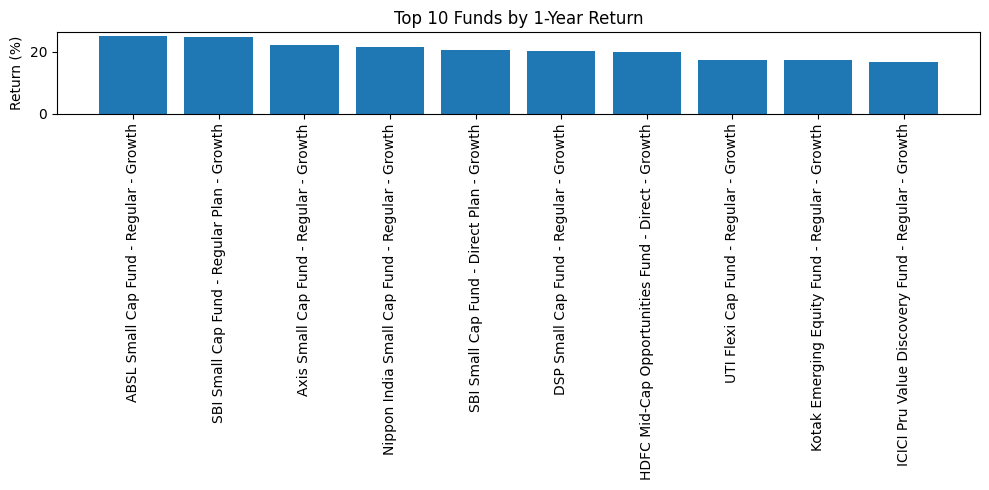

In [4]:
plt.figure(figsize=(10,5))

plt.bar(
    top_funds["scheme_name"],
    top_funds["return_1yr_pct"]
)

plt.xticks(rotation=90)
plt.title("Top 10 Funds by 1-Year Return")
plt.ylabel("Return (%)")

plt.tight_layout()
plt.show()

In [5]:
fund_house_perf = (
    performance
    .groupby("fund_house")["return_1yr_pct"]
    .mean()
    .sort_values(ascending=False)
)

fund_house_perf

fund_house
UTI Mutual Fund             15.830000
Axis Mutual Fund            15.655000
SBI Mutual Fund             15.632000
DSP Mutual Fund             15.426667
Aditya Birla Sun Life MF    15.310000
ICICI Prudential MF         13.866000
Mirae Asset MF              13.730000
Nippon India MF             13.578000
HDFC Mutual Fund            12.932000
Kotak Mahindra MF           12.872500
Name: return_1yr_pct, dtype: float64

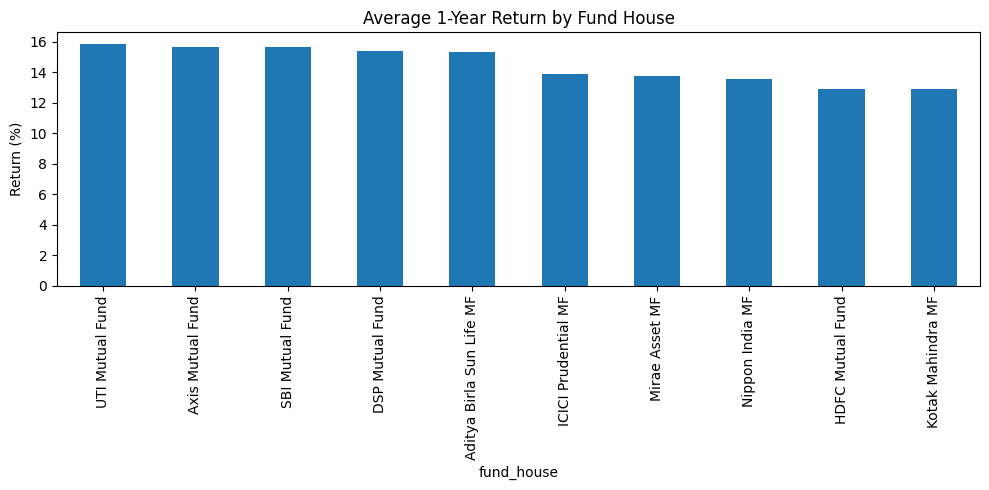

In [6]:
plt.figure(figsize=(10,5))

fund_house_perf.plot(kind="bar")

plt.title("Average 1-Year Return by Fund House")
plt.ylabel("Return (%)")

plt.tight_layout()
plt.show()

In [7]:
sip = pd.read_csv("../data/04_monthly_sip_inflows.csv")

sip["month"] = pd.to_datetime(sip["month"])

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


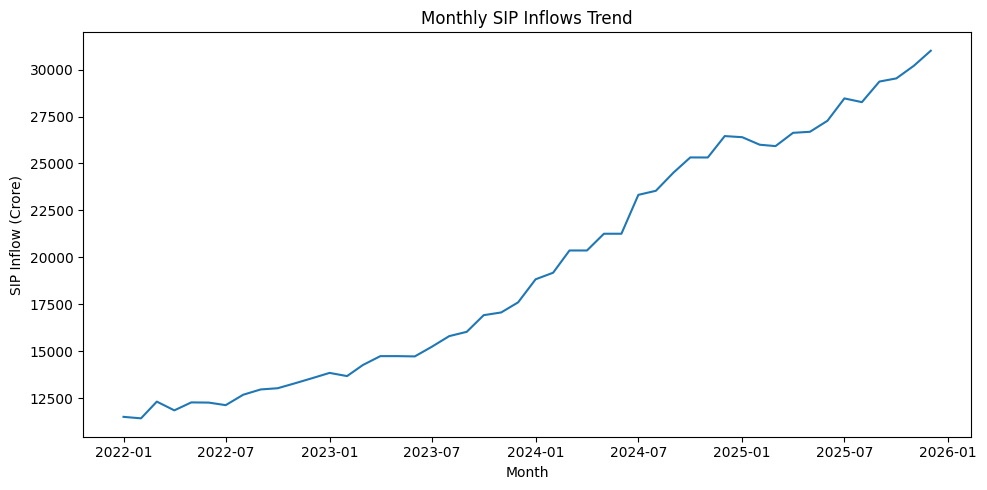

In [8]:
plt.figure(figsize=(10,5))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.title("Monthly SIP Inflows Trend")
plt.ylabel("SIP Inflow (Crore)")
plt.xlabel("Month")

plt.tight_layout()
plt.show()

In [9]:
transactions["transaction_type"].value_counts()

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

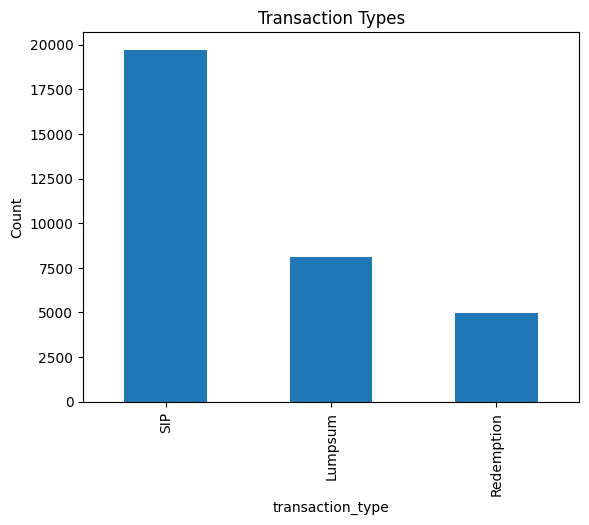

In [10]:
transactions["transaction_type"].value_counts().plot(
    kind="bar"
)

plt.title("Transaction Types")
plt.ylabel("Count")

plt.show()

In [11]:
transactions["gender"].value_counts()

gender
Male      21809
Female    10969
Name: count, dtype: int64

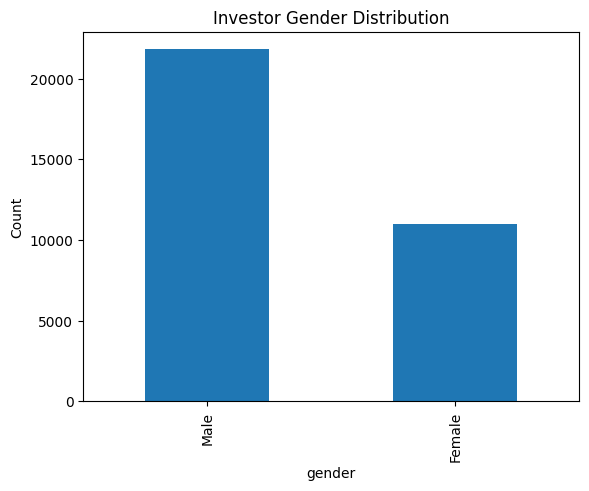

In [12]:
transactions["gender"].value_counts().plot(
    kind="bar"
)

plt.title("Investor Gender Distribution")
plt.ylabel("Count")

plt.show()

In [13]:
transactions["age_group"].value_counts()

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

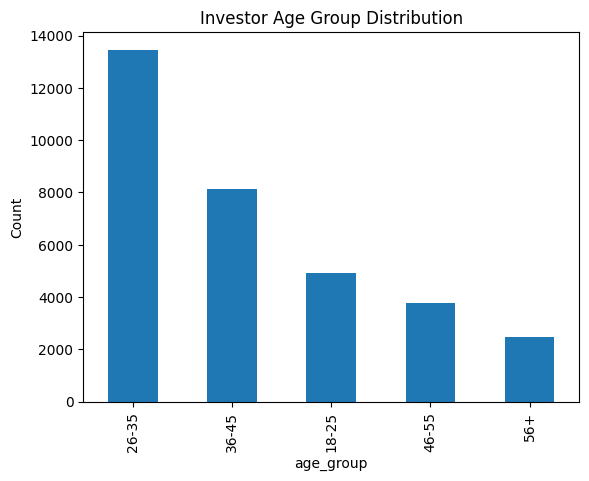

In [14]:
transactions["age_group"].value_counts().plot(
    kind="bar"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("Count")

plt.show()

In [15]:
transactions["state"].value_counts().head(10)

state
Punjab            2965
Madhya Pradesh    2931
Tamil Nadu        2806
Gujarat           2780
West Bengal       2748
Haryana           2736
Telangana         2718
Uttar Pradesh     2695
Delhi             2677
Karnataka         2621
Name: count, dtype: int64

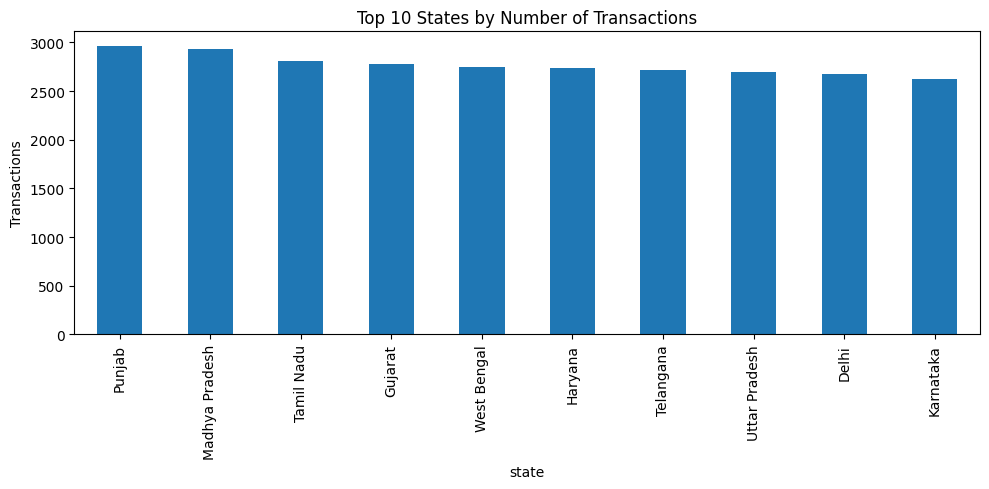

In [16]:
transactions["state"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 States by Number of Transactions")
plt.ylabel("Transactions")

plt.tight_layout()
plt.show()

In [17]:
transactions["kyc_status"].value_counts()

kyc_status
Verified    30146
Pending      2632
Name: count, dtype: int64

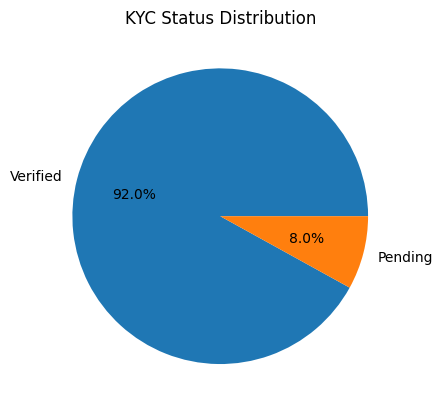

In [18]:
transactions["kyc_status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("KYC Status Distribution")
plt.ylabel("")
plt.show()

In [19]:
transactions["annual_income_lakh"].describe()

count    32778.000000
mean        26.181219
std         20.805425
min          3.000000
25%         10.600000
50%         19.700000
75%         37.400000
max         99.700000
Name: annual_income_lakh, dtype: float64

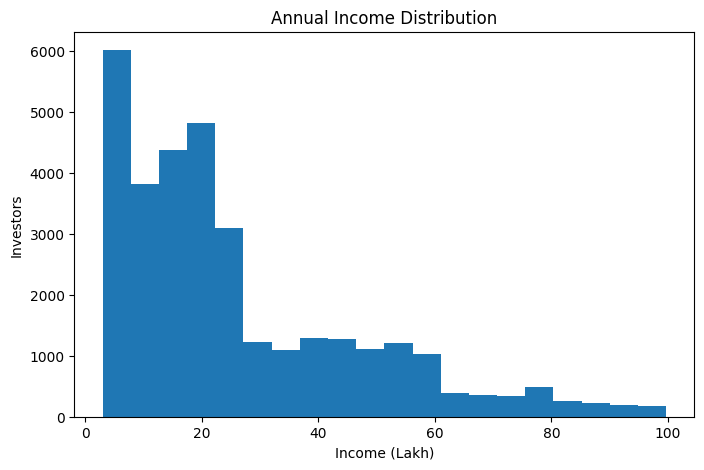

In [20]:
plt.figure(figsize=(8,5))

plt.hist(
    transactions["annual_income_lakh"],
    bins=20
)

plt.title("Annual Income Distribution")
plt.xlabel("Income (Lakh)")
plt.ylabel("Investors")

plt.show()

In [21]:
transactions["payment_mode"].value_counts()

payment_mode
Net Banking    8250
Cheque         8228
UPI            8154
Mandate        8146
Name: count, dtype: int64

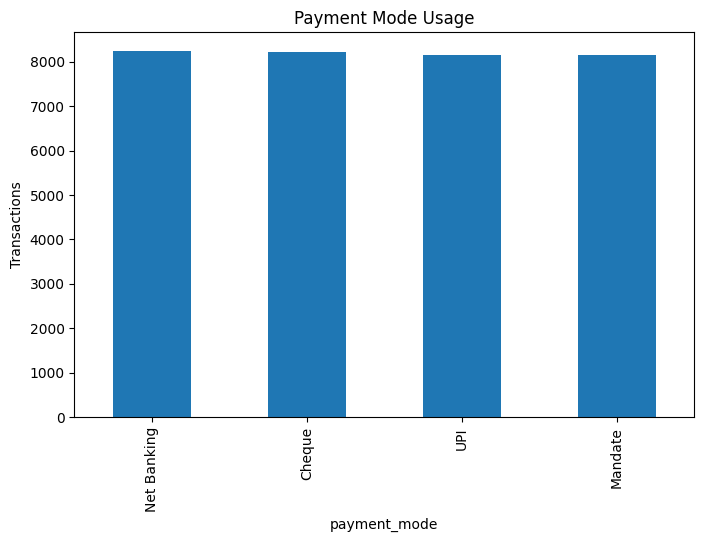

In [22]:
transactions["payment_mode"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Payment Mode Usage")
plt.ylabel("Transactions")

plt.show()

In [23]:
transactions["city"].value_counts().head(10)

city
Kolkata       2748
Hyderabad     2718
Gurugram      2126
Bhopal        1533
Amritsar      1528
Ahmedabad     1500
Faridabad     1483
Coimbatore    1478
Chandigarh    1437
Indore        1398
Name: count, dtype: int64

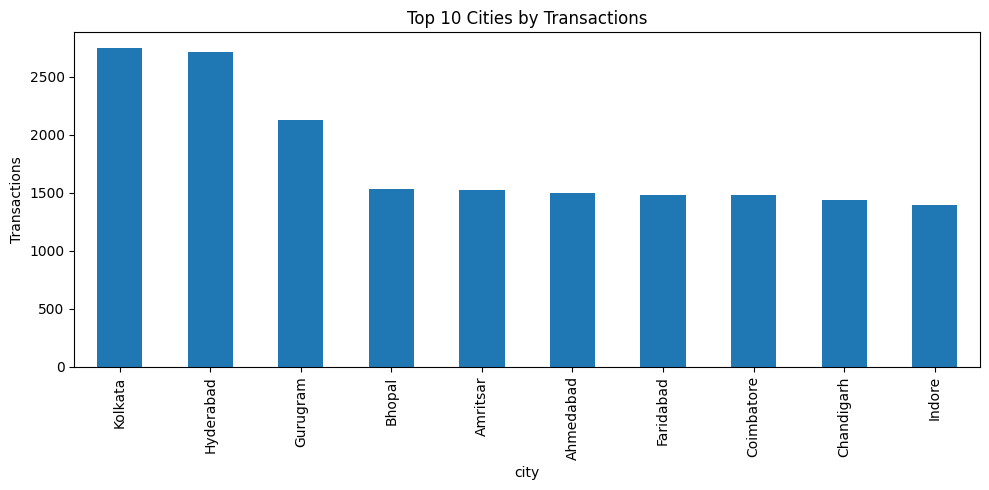

In [24]:
transactions["city"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Cities by Transactions")
plt.ylabel("Transactions")

plt.tight_layout()
plt.show()

In [25]:
performance["risk_grade"].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

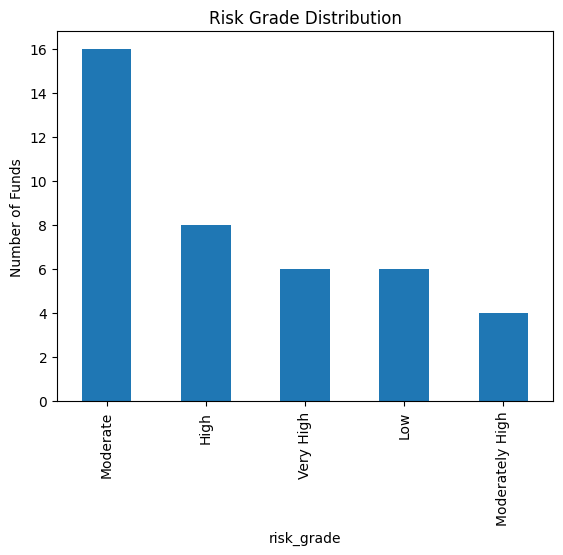

In [26]:
performance["risk_grade"].value_counts().plot(
    kind="bar"
)

plt.title("Risk Grade Distribution")
plt.ylabel("Number of Funds")

plt.show()

In [27]:
performance["morningstar_rating"].value_counts().sort_index()

morningstar_rating
3     7
4    16
5    17
Name: count, dtype: int64

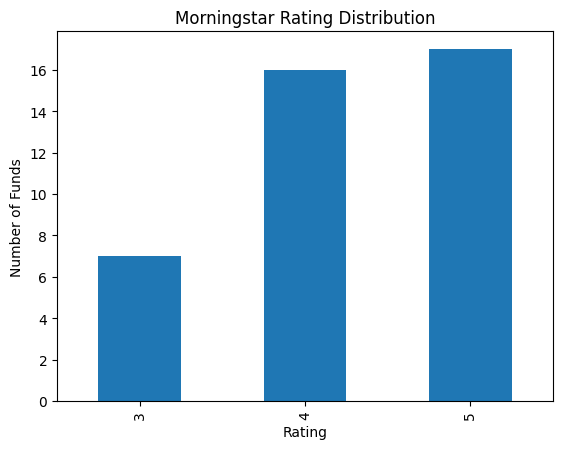

In [28]:
performance["morningstar_rating"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Morningstar Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Funds")

plt.show()

In [29]:
import seaborn as sns

In [30]:
cols = [
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct",
    "alpha",
    "beta",
    "sharpe_ratio",
    "std_dev_ann_pct",
    "expense_ratio_pct",
    "aum_crore"
]

corr = performance[cols].corr()

corr

,return_1yr_pct,return_3yr_pct,return_5yr_pct,alpha,beta,sharpe_ratio,std_dev_ann_pct,expense_ratio_pct,aum_crore
return_1yr_pct,1.000000,0.910491,0.879870,-0.195518,0.692502,-0.508997,0.907561,0.458151,0.096182
return_3yr_pct,0.910491,1.000000,0.929076,-0.231775,0.732442,-0.519123,0.956132,0.514664,0.062200
return_5yr_pct,0.879870,0.929076,1.000000,-0.228376,0.699485,-0.483935,0.940751,0.456199,0.143765
alpha,-0.195518,-0.231775,-0.228376,1.000000,-0.237821,0.235492,-0.300885,-0.233115,0.310481
beta,0.692502,0.732442,0.699485,-0.237821,1.000000,-0.709002,0.811858,0.561037,-0.087742
sharpe_ratio,-0.508997,-0.519123,-0.483935,0.235492,-0.709002,1.000000,-0.679069,-0.438824,0.185338
std_dev_ann_pct,0.907561,0.956132,0.940751,-0.300885,0.811858,-0.679069,1.000000,0.545995,0.027713
expense_ratio_pct,0.458151,0.514664,0.456199,-0.233115,0.561037,-0.438824,0.545995,1.000000,-0.009161
aum_crore,0.096182,0.062200,0.143765,0.310481,-0.087742,0.185338,0.027713,-0.009161,1.000000


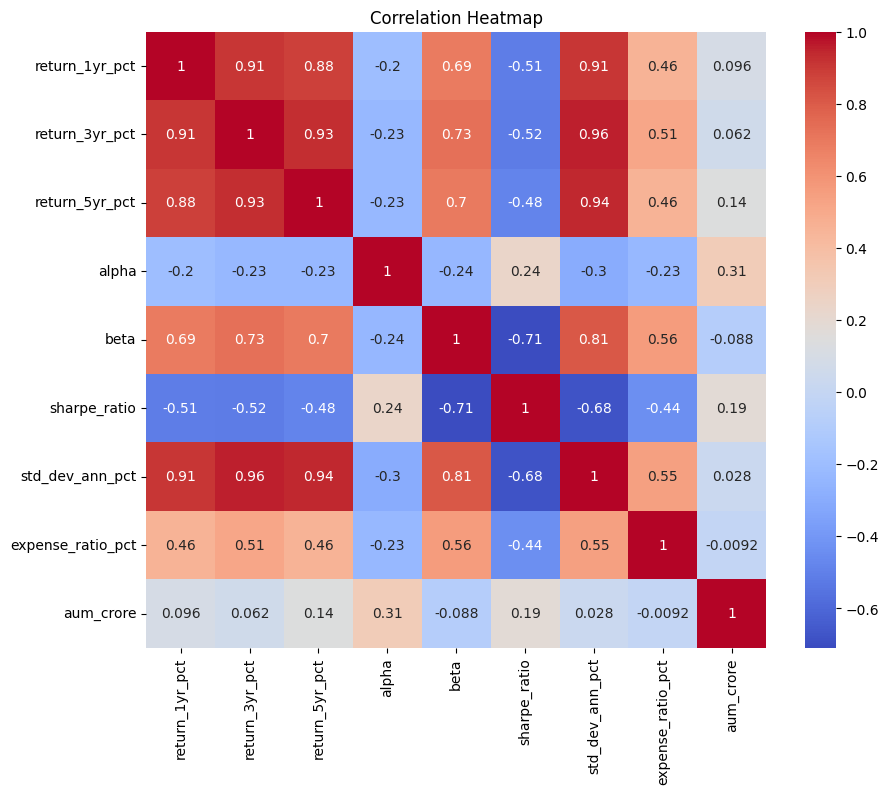

In [31]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [32]:
performance.groupby("category")["return_1yr_pct"].mean().sort_values(
    ascending=False
)

category
Small Cap          22.258333
Value              16.670000
Flexi Cap          16.585000
Mid Cap            15.978571
Large & Mid Cap    14.910000
Index              13.760000
Large Cap          13.724286
ELSS               11.160000
Index/ETF          10.140000
Short Duration      6.830000
Liquid              6.443333
Gilt                5.765000
Name: return_1yr_pct, dtype: float64

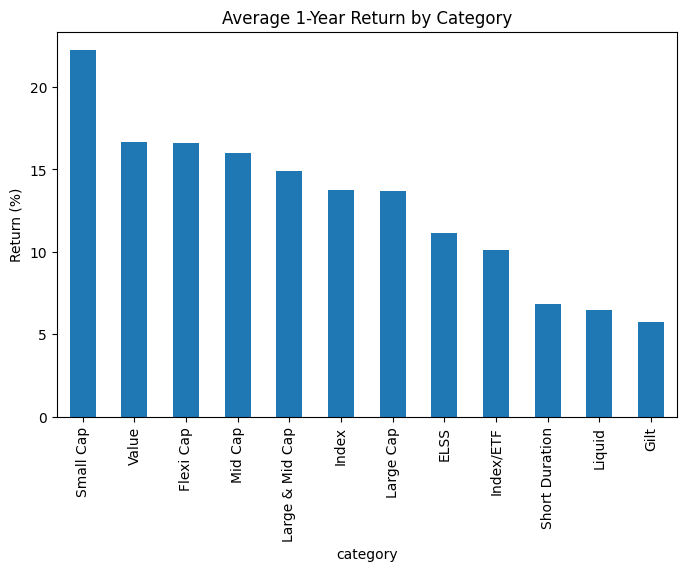

In [33]:
performance.groupby("category")["return_1yr_pct"].mean().sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average 1-Year Return by Category")
plt.ylabel("Return (%)")
plt.show()